In [30]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms, datasets
from PIL import Image
from glob import glob

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import seaborn as sns
from sklearn.preprocessing import label_binarize
import pandas as pd


## load dữ liệu, chia tập train, valid, test ngẫu nhiên theo tỉ lệ 9:0.5:0.5

In [7]:
# Định nghĩa đường dẫn thư mục chứa dữ liệu
data_dir = "data/cic_ddos_2019_images"
train_data, valid_data, test_data = [], [], []
label_map = {}  # Mapping nhãn -> số


for label_idx, label in enumerate(os.listdir(data_dir)):
    label_path = os.path.join(data_dir, label)
    if not os.path.isdir(label_path):
        continue
    
    # Lưu ánh xạ nhãn
    label_map[label] = label_idx
    
    # Lấy danh sách ảnh
    image_paths = glob(os.path.join(label_path, "*"))
    random.shuffle(image_paths)
    
    # Chia tập dữ liệu theo tỷ lệ 90:5:5
    ratito_1 = 0.9
    ratito_2 = 0.05

    total = len(image_paths)
    train_split = int(ratito_1 * total)
    valid_split = int((ratito_1+ratito_2) * total)

    train_data.extend([(p, label_idx) for p in image_paths[:train_split]])
    valid_data.extend([(p, label_idx) for p in image_paths[train_split:valid_split]])
    test_data.extend([(p, label_idx) for p in image_paths[valid_split:]])

In [8]:

# Kiểm tra số lượng mẫu mỗi tập
print(f"Train: {len(train_data)}, Valid: {len(valid_data)}, Test: {len(test_data)}")

# Hiển thị một số đường dẫn ảnh từ mỗi tập (kiểm tra kết quả)
print("Sample train images:", train_data[:3])
print("Sample valid images:", valid_data[:3])
print("Sample test images:", test_data[:3])
print("labels: ", label_map)

Train: 720, Valid: 40, Test: 40
Sample train images: [('data/cic_ddos_2019_images\\BENIGN\\47.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\8.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\89.png', 0)]
Sample valid images: [('data/cic_ddos_2019_images\\BENIGN\\76.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\91.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\17.png', 0)]
Sample test images: [('data/cic_ddos_2019_images\\BENIGN\\59.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\34.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\25.png', 0)]
labels:  {'BENIGN': 0, 'LDAP': 1, 'MSSQL': 2, 'NetBIOS': 3, 'Portmap': 4, 'Syn': 5, 'UDP': 6, 'UDPLag': 7}


## train model

In [9]:
# Định nghĩa Dataset
class ImageDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [10]:
# Định nghĩa các phép biến đổi dữ liệu
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize ảnh về kích thước chuẩn
    transforms.ToTensor(), # Chuyển ảnh thành tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Chuẩn hóa theo ImageNet
])

# Tạo DataLoader
batch_size = 32
train_loader = DataLoader(ImageDataset(train_data, transform), batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(ImageDataset(valid_data, transform), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(ImageDataset(test_data, transform), batch_size=batch_size, shuffle=False)

# Số lớp đầu ra
num_classes = len(label_map.keys())
print(num_classes)

8


In [11]:
# Kiểm tra thiết bị (GPU nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [12]:
# Tải mô hình MobileNet đã pretrained
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V2)

In [13]:
# Đóng băng toàn bộ trọng số của feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Thay thế classifier
model.classifier = nn.Sequential(
    nn.Linear(model.last_channel, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()  # Hàm mất mát
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)  # Chỉ tối ưu phần classifier


In [ ]:
num_epochs = 5
train_loss_history, val_loss_history = [], []
train_acc_history, val_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss /= len(valid_loader)
    val_acc = val_correct / val_total
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

print("Training completed.")


Epoch 1/10 -> Train Loss: 1.9375, Train Acc: 0.2944, Val Loss: 1.8612, Val Acc: 0.4000
Epoch 2/10 -> Train Loss: 1.4270, Train Acc: 0.5875, Val Loss: 1.3474, Val Acc: 0.6250
Epoch 3/10 -> Train Loss: 1.0483, Train Acc: 0.6944, Val Loss: 1.0257, Val Acc: 0.7000
Epoch 4/10 -> Train Loss: 0.8069, Train Acc: 0.7528, Val Loss: 0.7456, Val Acc: 0.7750
Epoch 5/10 -> Train Loss: 0.6713, Train Acc: 0.8028, Val Loss: 0.7027, Val Acc: 0.8250
Epoch 6/10 -> Train Loss: 0.5471, Train Acc: 0.8542, Val Loss: 0.5568, Val Acc: 0.8500
Epoch 7/10 -> Train Loss: 0.4635, Train Acc: 0.8681, Val Loss: 0.5647, Val Acc: 0.8500
Epoch 8/10 -> Train Loss: 0.4051, Train Acc: 0.8917, Val Loss: 0.4581, Val Acc: 0.9000
Epoch 9/10 -> Train Loss: 0.3272, Train Acc: 0.9264, Val Loss: 0.4854, Val Acc: 0.8750
Epoch 10/10 -> Train Loss: 0.3134, Train Acc: 0.9153, Val Loss: 0.5993, Val Acc: 0.8500
Training completed.


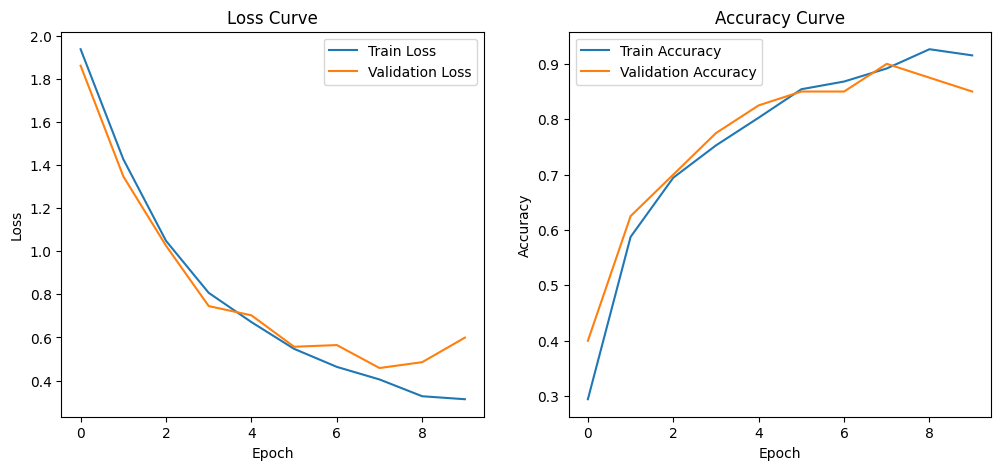

In [16]:
#  Vẽ biểu đồ Loss Curve và Accuracy Curve
plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()


## đánh giá

In [28]:
test_correct, test_total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = test_correct / test_total
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.8750


In [17]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=label_map.keys()))


              precision    recall  f1-score   support

      BENIGN       0.67      0.80      0.73         5
        LDAP       0.71      1.00      0.83         5
       MSSQL       1.00      0.80      0.89         5
     NetBIOS       1.00      0.60      0.75         5
     Portmap       1.00      1.00      1.00         5
         Syn       1.00      0.80      0.89         5
         UDP       0.83      1.00      0.91         5
      UDPLag       1.00      1.00      1.00         5

    accuracy                           0.88        40
   macro avg       0.90      0.88      0.87        40
weighted avg       0.90      0.88      0.87        40



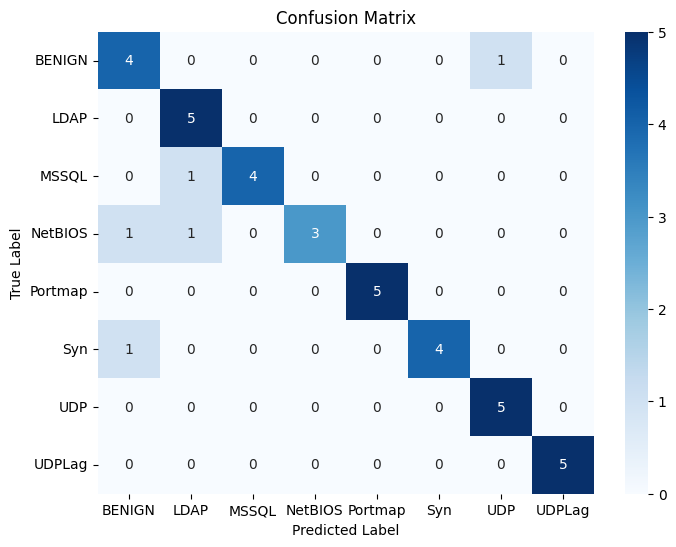

In [18]:
#  Vẽ Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


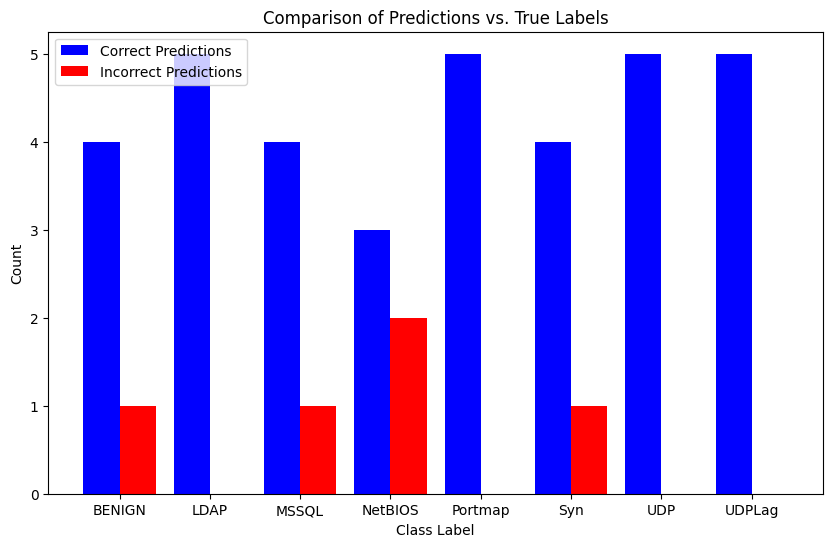

In [32]:
# Tạo DataFrame chứa nhãn thực tế và dự đoán
df = pd.DataFrame({"True Label": all_labels, "Predicted Label": all_preds})

# Đếm số lượng dự đoán đúng và sai theo từng lớp
df["Correct"] = (df["True Label"] == df["Predicted Label"])  # True nếu dự đoán đúng

# Đếm số lượng đúng/sai theo từng lớp
correct_counts = df[df["Correct"]].groupby("True Label").size()
incorrect_counts = df[~df["Correct"]].groupby("True Label").size()

# Đảm bảo tất cả nhãn có trong bảng
correct_counts = correct_counts.reindex(range(num_classes), fill_value=0)
incorrect_counts = incorrect_counts.reindex(range(num_classes), fill_value=0)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.4
index = np.arange(num_classes)

plt.bar(index, correct_counts, bar_width, label="Correct Predictions", color="blue")
plt.bar(index + bar_width, incorrect_counts, bar_width, label="Incorrect Predictions", color="red")

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Comparison of Predictions vs. True Labels")
plt.xticks(index + bar_width / 2, label_map.keys(), rotation=0)
plt.legend()
plt.show()